The goal of this home work is to develop a system in which it predicts 

### Return Prediction 

In [1]:
# =============================================================================
# DATA SPLITTING (PER STOCK, PER MONTH)
# =============================================================================
import pandas as pd

# Load the full combined dataset
print("Loading data_stock_full.csv...")
df = pd.read_csv("data/data_stock_full.csv")

# Ensure it's strictly sorted chronologically per ticker
df.sort_values(by=['ticker', 'timestamp'], inplace=True)

# Add a year-month column for temporal splitting
df['year_month'] = pd.to_datetime(df['timestamp']).dt.to_period('M')

# We perform a random scatter split for EACH stock, strictly proportional PER MONTH
# 80% for training, 20% for testing.
train_fraction = 0.8
print(f"Splitting data randomly ({int(train_fraction*100)}/{int((1-train_fraction)*100)}) per stock AND per month...")

def split_stock(group):
    # Randomly sample 80% of each month for train
    g_train = group.groupby('year_month', group_keys=False).apply(lambda x: x.sample(frac=train_fraction, random_state=42))
    g_test = group.drop(g_train.index)
    return g_train, g_test

train_list = []
test_list = []

for ticker, group in df.groupby('ticker'):
    g_train, g_test = split_stock(group)
    train_list.append(g_train)
    test_list.append(g_test)

train_df = pd.concat(train_list).reset_index(drop=True)
test_df = pd.concat(test_list).reset_index(drop=True)

# Drop the temporary year_month column safely
if 'year_month' in train_df.columns:
    train_df.drop(columns=['year_month'], inplace=True)
if 'year_month' in test_df.columns:
    test_df.drop(columns=['year_month'], inplace=True)

# Sort the final sets to maintain order in their chunks
train_df.sort_values(by=['ticker', 'timestamp'], inplace=True)
test_df.sort_values(by=['ticker', 'timestamp'], inplace=True)

print(f"Train set shape: {train_df.shape}")
print(f"Test set shape:  {test_df.shape}")

train_df.to_csv("data/dataset_train.csv", index=False)
test_df.to_csv("data/dataset_test.csv", index=False)

print("Saved 'data/dataset_train.csv' and 'data/dataset_test.csv' successfully!")

Loading data_stock_full.csv...
Splitting data randomly (80/19) per stock AND per month...
Train set shape: (171001, 21)
Test set shape:  (41803, 21)
Saved 'data/dataset_train.csv' and 'data/dataset_test.csv' successfully!


In [2]:
import os
import pandas as pd

log_path = "data/train_test_statistics.log"

print('=== TRAIN/TEST SPLIT STATISTICS PER TICKER ===')

# Calculate samples per ticker
train_counts = train_df['ticker'].value_counts().rename('Train Samples')
test_counts = test_df['ticker'].value_counts().rename('Test Samples')

# Combine and format
split_stats = pd.concat([train_counts, test_counts], axis=1).fillna(0).astype(int)
split_stats.index.name = 'Ticker'
split_stats.reset_index(inplace=True)
split_stats['Total Samples'] = split_stats['Train Samples'] + split_stats['Test Samples']

# Sort alphabetically by ticker for a clean list
split_stats.sort_values('Ticker', inplace=True)

# Generate global summary
global_stats = [
    f"Total Train Samples: {len(train_df):,}",
    f"Total Test Samples:  {len(test_df):,}",
    f"Total Unique Tickers: {train_df['ticker'].nunique()}",
    f"Train Date Range: {train_df['timestamp'].min()} to {train_df['timestamp'].max()}",
    f"Test Date Range:  {test_df['timestamp'].min()} to {test_df['timestamp'].max()}",
    ""
]

for line in global_stats:
    print(line)
    
print(split_stats.to_string(index=False))

# Save to log file
with open(log_path, 'w') as f:
    f.write('=== TRAIN/TEST SPLIT STATISTICS PER TICKER ===\n\n')
    f.write('\n'.join(global_stats) + '\n')
    f.write(split_stats.to_string(index=False) + '\n')

print(f"\nStatistics successfully saved to '{log_path}'!")

=== TRAIN/TEST SPLIT STATISTICS PER TICKER ===
Total Train Samples: 171,001
Total Test Samples:  41,803
Total Unique Tickers: 44
Train Date Range: 2000-02-15 to 2026-03-16
Test Date Range:  2000-02-18 to 2026-03-11

    Ticker  Train Samples  Test Samples  Total Samples
  ADANIENT           4630          1133           5763
ADANIPORTS           3627           891           4518
APOLLOHOSP           4584          1120           5704
ASIANPAINT           4584          1120           5704
  AXISBANK           4598          1124           5722
BAJAJ-AUTO           3533           866           4399
BAJAJFINSV           3532           866           4398
BAJFINANCE           4583          1120           5703
       BEL           4584          1120           5704
BHARTIARTL           4598          1124           5722
     CIPLA           4584          1120           5704
 COALINDIA           3049           748           3797
   DRREDDY           3220           788           4008
 EICHERMOT    

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader

class StockDataset(Dataset):
    def __init__(self, data_path, ticker=None, seq_len=30, scaler=None):
        self.seq_len = seq_len
        self.ticker = ticker
        
        # 1. Load data
        df = pd.read_csv(data_path)
        
        # 2. Filter ticker if specified (None means train on ALL tickers)
        if ticker:
            df = df[df['ticker'] == ticker].copy()
            
        df.sort_values(['ticker', 'timestamp'], inplace=True)
        
        # 3. Use precomputed features from the new dataset
        self.feature_cols = [
            'open', 'high', 'low', 'close', 'volume', 
            'ret_5', 'ret_30', 'rel_ret_5', 'rank_ret_5', 
            'vol_30', 'risk_adj_ret', 'vol_z', 'pv_signal', 
            'dist_high', 'z_price', 'residual', 'market_ret_5', 'corr_market_30'
        ]
        
        # Ensure all columns exist, fill any missing NaNs
        for col in self.feature_cols:
            if col not in df.columns:
                df[col] = 0.0
                
        df.replace([np.inf, -np.inf], 0, inplace=True)
        df.fillna(0, inplace=True)
        
        # 4. Target: Next day's aligned return mapped by ticker
        df['target'] = df.groupby('ticker')['return'].shift(-1)
        df.dropna(subset=['target'], inplace=True)
        
        features = df[self.feature_cols].values
        targets = df['target'].values
        tickers_list = df['ticker'].values
        
        # 5. Normalize features safely (avoiding double normalization if already norm'd, 
        # but standardized strictly on the current split context to avoid leakage)
        if scaler is None:
            self.mean = np.nanmean(features, axis=0)
            self.std = np.nanstd(features, axis=0)
            self.std = np.where(self.std == 0, 1.0, self.std)  
        else:
            self.mean, self.std = scaler
            
        features = (features - self.mean) / (self.std + 1e-8)
        
        # 6. Extract Valid Sequences strictly per ticker
        self.valid_indices = []
        for i in range(len(features) - self.seq_len):
            if tickers_list[i] == tickers_list[i + self.seq_len - 1]:
                self.valid_indices.append(i)
                
        self.x_data = features
        self.y_data = targets
            
    def __len__(self):
        return len(self.valid_indices)
        
    def __getitem__(self, i):
        idx = self.valid_indices[i]
        x = self.x_data[idx:idx + self.seq_len]
        y = self.y_data[idx + self.seq_len - 1] # target predicting the next step
        
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

def get_dataloaders(train_path, val_path, ticker=None, seq_len=30, batch_size=32):
    # Load strictly the train dataset chronologically
    train_dataset = StockDataset(train_path, ticker=ticker, seq_len=seq_len)
    
    # Pass the training scaler to the validation dataset to prevent test data leakage
    scaler = (train_dataset.mean, train_dataset.std)
    val_dataset = StockDataset(val_path, ticker=ticker, seq_len=seq_len, scaler=scaler)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# =============================================================================
# 1. MODEL ARCHITECTURE 
# =============================================================================

class ResidualConvBlock(nn.Module):
    """
    Deep residual block to allow stacking more layers without vanishing gradients.
    This increases parameter count and helps learn complex hierarchical patterns.
    """
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv1d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(channels)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        residual = x
        out = F.gelu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        out += residual  # Skip connection
        return F.gelu(out)

class MultiWindowFeatureExtractor(nn.Module):
    """
    Extracts patterns using different window sizes (Short, Medium, Long term).
    """
    def __init__(self, input_dims, output_dims):
        super().__init__()
        self.short_conv = nn.Conv1d(input_dims, output_dims, kernel_size=3, padding=1)
        self.mid_conv = nn.Conv1d(input_dims, output_dims, kernel_size=5, padding=2)
        self.long_conv = nn.Conv1d(input_dims, output_dims, kernel_size=7, padding=3)
        self.batch_norm = nn.BatchNorm1d(output_dims * 3)
        self.dropout_layer = nn.Dropout(0.3)

    def forward(self, x):
        out_short = self.short_conv(x)
        out_mid   = self.mid_conv(x)
        out_long  = self.long_conv(x)
        combined = torch.cat([out_short, out_mid, out_long], dim=1)
        return self.dropout_layer(F.gelu(self.batch_norm(combined)))

class StockPricePredictor(nn.Module):
    def __init__(self, num_features, hidden_size=128): # Increased default hidden_size
        super().__init__()
        self.initial_norm = nn.BatchNorm1d(num_features)
        
        # 1. Multi-scale feature extraction
        self.feature_block = MultiWindowFeatureExtractor(num_features, hidden_size)
        self.compression = nn.Conv1d(hidden_size * 3, hidden_size, kernel_size=1)
        
        # 2. Deep Residual Blocks to boost parameter count and feature depth
        self.res_blocks = nn.Sequential(
            ResidualConvBlock(hidden_size),
            ResidualConvBlock(hidden_size),
            ResidualConvBlock(hidden_size)
        )
        
        # 3. Deeper, wider output head
        self.output_head = nn.Sequential(
            nn.Linear(hidden_size, 128),
            nn.GELU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.4),
            
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(0.4),
            
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x input shape: (batch_size, seq_len, features)
        x = x.transpose(1, 2)  # shape: (batch_size, features, seq_len)
        x = self.initial_norm(x)
        
        x = self.feature_block(x)
        x = F.gelu(self.compression(x))
        
        x = self.res_blocks(x)  # Pass through deep residual layers
        
        # Global Pooling (Average + Max)
        avg_pool = torch.mean(x, dim=-1)
        max_pool, _ = torch.max(x, dim=-1)
        pooled_output = (avg_pool + max_pool) / 2
        
        return self.output_head(pooled_output).squeeze(-1)


# =============================================================================
# 2. TRAINING (The Trainer) 
# =============================================================================

class StockModelTrainer:
    """
    Handles the training and validation loops with robust loss and optimizers.
    """
    def __init__(self, model, learning_rate=3e-4, weight_decay=1e-3, device=None):
        self.device = device if device else ('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = model.to(self.device)
        # Using AdamW for better regularization than standard Adam
        self.optimizer = torch.optim.AdamW(
            self.model.parameters(), 
            lr=learning_rate, 
            weight_decay=weight_decay
        )
        self.loss_fn = nn.HuberLoss(delta=1.0)
        self.lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.5, patience=5
        )

    def compute_directional_accuracy(self, preds, targets):
        """
        Calculates what percentage of the time the model correctly guessed 
        if the stock would go UP or DOWN, ignoring the exact magnitude.
        """
        correct_direction = (torch.sign(preds) == torch.sign(targets)).float()
        return correct_direction.mean().item() * 100

    def run_training_step(self, dataloader, is_train=True):
        if is_train:
            self.model.train()
        else:
            self.model.eval()
            
        total_loss = 0.0
        total_dir_acc = 0.0
        total_mae = 0.0

        with torch.set_grad_enabled(is_train):
            for batch_idx, (batch_x, batch_y) in enumerate(dataloader):
                batch_x = batch_x.to(self.device)
                batch_y = batch_y.to(self.device)

                if is_train:
                    self.optimizer.zero_grad()

                predictions = self.model(batch_x)
                loss = self.loss_fn(predictions, batch_y)

                if is_train:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                    self.optimizer.step()

                total_loss += loss.item()
                acc = self.compute_directional_accuracy(predictions, batch_y)
                mae = torch.abs(predictions - batch_y).mean().item()
                
                total_dir_acc += acc
                total_mae += mae
                
                # Print batch-wise status using carriage return
                mode = "Train" if is_train else "Val  "
                print(f"\r  {mode} Batch {batch_idx+1:4d}/{len(dataloader)} | Loss: {loss.item():.4f} | Dir Acc: {acc:6.2f}% | MAE: {mae:.5f}     ", end="", flush=True)

        print() # new line after epoch phase completes
            
        avg_loss = total_loss / len(dataloader)
        avg_dir_acc = total_dir_acc / len(dataloader)
        avg_mae = total_mae / len(dataloader)
        
        return avg_loss, avg_dir_acc, avg_mae

    def run_validation(self, dataloader):
        val_loss, val_dir_acc, val_mae = self.run_training_step(dataloader, is_train=False)
        self.lr_scheduler.step(val_loss)
        return val_loss, val_dir_acc, val_mae


# =============================================================================
# 3. MAIN SCRIPT
# =============================================================================
if __name__ == "__main__":
    FEATURES_COUNT = 18
    LOOKBACK_WINDOW = 30
    BATCH_SIZE = 128    
    EPOCHS = 100        
    TRAIN_DATA_PATH = "data/dataset_train.csv"
    VAL_DATA_PATH = "data/dataset_test.csv"
    MODEL_SAVE_PATH = "model.pth"
    PATIENCE = 30     
    
    # 1. Create Model (capacity expanded via higher hidden_size and residual layers)
    my_model = StockPricePredictor(num_features=FEATURES_COUNT, hidden_size=128)
    
    # 2. Create Trainer
    my_trainer = StockModelTrainer(model=my_model, learning_rate=5e-4)
    
    # Print Param Count
    total_params = sum(p.numel() for p in my_model.parameters() if p.requires_grad)
    print(f"Total Trainable Parameters: {total_params:,}")
    
    # 3. Load Data & Train
    try:
        from torch.utils.data import DataLoader
        print(f"Loading strictly Train split from {TRAIN_DATA_PATH}")
        print(f"Loading strictly Test split from {VAL_DATA_PATH}")
        
        train_loader, val_loader = get_dataloaders(TRAIN_DATA_PATH, VAL_DATA_PATH, ticker=None, seq_len=LOOKBACK_WINDOW, batch_size=BATCH_SIZE)
        
        print(f"\nData loaded! Found {len(train_loader.dataset):,} training samples and {len(val_loader.dataset):,} validation samples across ALL tickers.")
        print("Starting Training ...\n")
        
        best_val_loss = float('inf')
        epochs_no_improve = 0

        # Lists to store metrics for visualization
        base_train_losses = []
        base_val_losses = []

        for epoch in range(EPOCHS):
            print(f"Epoch {epoch+1:03d}/{EPOCHS} " + "="*50)
            train_loss, train_dir_acc, train_mae = my_trainer.run_training_step(train_loader, is_train=True)
            val_loss, val_dir_acc, val_mae = my_trainer.run_validation(val_loader)
            
            base_train_losses.append(train_loss)
            base_val_losses.append(val_loss)
            
            # EARLY STOPPING LOGIC & BEST MODEL CHECKPOINT
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                epochs_no_improve = 0
                torch.save(my_model.state_dict(), MODEL_SAVE_PATH)
                saved_flag = "  [✓ BEST SAVED]"
            else:
                epochs_no_improve += 1
                saved_flag = ""
                
            print(f"  -> Summary: Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train Dir Acc: {train_dir_acc:.2f}% | Val Dir Acc: {val_dir_acc:.2f}% | Train MAE: {train_mae:.5f} | Val MAE: {val_mae:.5f}{saved_flag}\n")
            
            if epochs_no_improve >= PATIENCE:
                print(f"\nEarly stopping triggered after {epoch+1} epochs! Val loss has not improved for {PATIENCE} epochs.")
                break
                
        print(f"\nTraining Complete! Best model was saved to: {MODEL_SAVE_PATH} with Best Validation Loss: {best_val_loss:.6f}")
        
    except Exception as e:
        import traceback
        print(f"Error loading dataset or training: {e}")
        traceback.print_exc()

Total Trainable Parameters: 407,333
Loading strictly Train split from data/dataset_train.csv
Loading strictly Test split from data/dataset_test.csv

Data loaded! Found 169,680 training samples and 40,482 validation samples across ALL tickers.
Starting Training ...

Epoch 001/100 ==================================================
  Train Batch 1325/1325 | Loss: 0.2464 | Dir Acc:  36.72% | MAE: 0.47133     
  Val   Batch  317/317 | Loss: 0.0007 | Dir Acc:   0.00% | MAE: 0.02718     
  -> Summary: Train Loss: 0.2588 | Val Loss: 0.2506 | Train Dir Acc: 33.02% | Val Dir Acc: 32.07% | Train MAE: 0.50399 | Val MAE: 0.48217  [✓ BEST SAVED]

Epoch 002/100 ==================================================
  Train Batch 1325/1325 | Loss: 0.3396 | Dir Acc:  43.75% | MAE: 0.58281     
  Val   Batch  317/317 | Loss: 0.0008 | Dir Acc:   0.00% | MAE: 0.03007     
  -> Summary: Train Loss: 0.2467 | Val Loss: 0.2515 | Train Dir Acc: 37.08% | Val Dir Acc: 31.73% | Train MAE: 0.48138 | Val MAE: 0.47473



In [5]:
# =============================================================================
# 4. EVALUATION & INFERENCE (PER STOCK METRICS)
# =============================================================================
import torch
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader

# Configuration
EVAL_START_DATE = None  # e.g., "2023-01-01" (set to None to evaluate all)
EVAL_END_DATE   = None  # e.g., "2023-12-31" (set to None to evaluate all)
NUM_DAYS_TO_SHOW = 10   # Number of days to display per stock from the date range
MAX_STOCKS = 50         # Number of stocks to evaluate

# 1. Load the BEST saved model weights
# Using MODEL_SAVE_PATH from the training cell
best_model_path = globals().get('MODEL_SAVE_PATH', "model.pth")
print(f"Loading best model weights from {best_model_path}...")
my_model.load_state_dict(torch.load(best_model_path, map_location=my_trainer.device, weights_only=True))
my_model.eval()

# 2. Extract global scaler from the training loader (to prevent data leakage)
global_scaler = (train_loader.dataset.mean, train_loader.dataset.std)

# 3. Load the testing dataset to get unique tickers
test_df_raw = pd.read_csv("data/dataset_test.csv")
tickers = test_df_raw['ticker'].dropna().unique()[:MAX_STOCKS]

stock_summaries = []

print(f"\nStarting detailed per-stock evaluation for {len(tickers)} stocks...")
if EVAL_START_DATE or EVAL_END_DATE:
    print(f"Filtering Date Range: {EVAL_START_DATE or 'Start'} to {EVAL_END_DATE or 'End'}")
print("="*65)

for ticker in tickers:
    # Build a dedicated loader exclusively for this ticker's test data
    seq_length = globals().get('LOOKBACK_WINDOW', 30)
    ticker_dataset = StockDataset("data/dataset_test.csv", ticker=ticker, seq_len=seq_length, scaler=global_scaler)
    
    if len(ticker_dataset) == 0:
        continue
        
    ticker_loader = DataLoader(ticker_dataset, batch_size=128, shuffle=False)
    
    all_preds = []
    all_truths = []
    
    # Run Inference
    with torch.no_grad():
        for batch_x, batch_y in ticker_loader:
            batch_x = batch_x.to(my_trainer.device)
            preds = my_model(batch_x)
            
            all_preds.extend(preds.cpu().numpy())
            all_truths.extend(batch_y.numpy())
            
    all_preds = np.array(all_preds)
    all_truths = np.array(all_truths)
    
    # --- Recover Dates for Dataframe Alignment ---
    ticker_df = test_df_raw[test_df_raw['ticker'] == ticker].copy()
    ticker_df.sort_values(by=['timestamp'], inplace=True)
    
    # Emulate the target shift used in dataset creation
    ticker_df['target'] = ticker_df['return'].shift(-1)
    ticker_df.dropna(subset=['target'], inplace=True)
    
    # Extract matching timestamps (aligning with seq_length delays)
    target_dates = ticker_df['timestamp'].values[seq_length - 1 : seq_length - 1 + len(all_truths)]
    min_len = min(len(target_dates), len(all_truths))
    
    # Combine everything into an evaluation DataFrame
    res_df = pd.DataFrame({
        'Date': target_dates[:min_len],
        'Ground Truth Return (%)': all_truths[:min_len] * 100,
        'Predicted Return (%)': all_preds[:min_len] * 100,
        'Absolute Error (%)': np.abs(all_truths[:min_len] - all_preds[:min_len]) * 100
    })
    
    # --- Apply Date Range Filter ---
    if EVAL_START_DATE:
        res_df = res_df[res_df['Date'] >= EVAL_START_DATE]
    if EVAL_END_DATE:
        res_df = res_df[res_df['Date'] <= EVAL_END_DATE]
        
    if len(res_df) == 0:
        continue
        
    # Re-extract filtered arrays for accurate per-range metrics
    filtered_truths = res_df['Ground Truth Return (%)'].values / 100.0
    filtered_preds = res_df['Predicted Return (%)'].values / 100.0
    
    # Calculate Per-Stock Metrics based on Filtered Range
    correct_direction = (np.sign(filtered_preds) == np.sign(filtered_truths)).astype(float)
    dir_acc = correct_direction.mean() * 100
    mae = np.mean(np.abs(filtered_truths - filtered_preds))
    rmse = np.sqrt(np.mean((filtered_truths - filtered_preds)**2))
    
    stock_summaries.append({
        'Ticker': ticker,
        'Eval Days': len(res_df),
        'Dir Acc (%)': dir_acc,
        'MAE (%)': mae * 100,
        'RMSE (%)': rmse * 100
    })
    
    # Slice the last N days for the print layout
    tail_df = res_df.tail(NUM_DAYS_TO_SHOW)
    
    print(f"\n[{ticker}] - Performance for Date Range (Showing Last {len(tail_df)} evaluated days)")
    print(tail_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# 4. Generate Final Statistics Table
if not stock_summaries:
    print("\nNo data found for the given date range.")
else:
    summary_df = pd.DataFrame(stock_summaries)

    print("\n\n" + "="*80)
    print("  FINAL PER-STOCK VALIDATION STATISTICS (DATE FILTERED)  ")
    print("="*80)
    print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
    print("="*80)

    # Calculate global ensemble averages
    global_dir_acc = summary_df['Dir Acc (%)'].mean()
    global_mae = summary_df['MAE (%)'].mean()

    print(f"\nAVERAGE ACROSS {len(summary_df)} STOCKS (Date Range Filtered):")
    print(f"Average Directional Accuracy: {global_dir_acc:.2f}%")
    print(f"Average MAE: {global_mae:.3f}%\n")

Loading best model weights from model.pth...

Starting detailed per-stock evaluation for 44 stocks...

[ADANIENT] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2025-12-19                  45.9429               16.6921             29.2508
2025-12-29                  77.9809               16.3967             61.5843
2026-01-09                  20.4173               14.0163              6.4010
2026-01-12                  57.5040               10.4261             47.0778
2026-01-16                -165.1208                9.5198            174.6406
2026-01-22                 -44.2171                7.9903             52.2074
2026-02-09                  -7.8430               -6.0386              1.8044
2026-02-13                -103.6355                2.1517            105.7871
2026-02-19                -176.8431                9.2060            186.0491
2026-02-26                 131.6628         

In [ ]:
# =============================================================================
# OPTIONAL TEST: OVERALL DIRECTIONAL ACCURACY ON VALIDATION SET
# =============================================================================

my_model.eval()
all_preds = []
all_targets = []

print("Evaluating directional accuracy on test data...")
with torch.no_grad():
    for batch_x, batch_y in val_loader:
        # In case the val_loader is returning portfolio format (batch, stocks, seq, features), 
        # we flatten it back out for the base predictor
        if batch_x.dim() == 4:
            batch_size, num_stocks, seq_len, num_features = batch_x.shape
            batch_x = batch_x.view(-1, seq_len, num_features)
            batch_y = batch_y.view(-1)
            
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        preds = my_model(batch_x)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(batch_y.cpu().numpy())

all_preds = np.concatenate(all_preds).flatten()
all_targets = np.concatenate(all_targets).flatten()

# Mask to ignore examples where true return is exactly 0
mask = all_targets != 0.0
filtered_preds = all_preds[mask]
filtered_targets = all_targets[mask]

correct_direction = (np.sign(filtered_preds) == np.sign(filtered_targets)).astype(float)
dir_acc = correct_direction.mean() * 100

print(f"\n==============================================")
print(f"  Test Directional Accuracy   : {dir_acc:.2f}%")
print(f"  Total Valid Evaluated Samples: {len(filtered_targets)}")
print(f"==============================================\n")


Evaluating directional accuracy on test data...


ValueError: expected 2D or 3D input (got 4D input)

Loading best model weights from master_50_stock_model.pth...

Starting detailed per-stock evaluation for 50 stocks...
Filtering Date Range: 2024-01-01 to 2024-01-31
=================================================================

[ADANIENT] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                 -11.1405                2.2840             13.4245
2024-01-18                 244.7802                2.4548            242.3254
2024-01-19                   0.0000                2.5097              2.5097
2024-01-20                  23.7931                2.4932             21.2999
2024-01-23                 -33.9828                2.5228             36.5057
2024-01-24                   0.0000                2.5348              2.5348
2024-01-25                  85.9364                2.6378             83.2986
2024-01-29                 163.3253                2.6167            160.7086
2024-01-30                  36.5341                2.5970             33.9371
2024-01-31                  12.5179                2.4679             10.0500

[ADANIPORTS] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                 -13.8738                1.9221             15.7959
2024-01-18                 345.8103                2.0778            343.7325
2024-01-19                   0.0000                2.1023              2.1023
2024-01-20                -146.1691                2.1013            148.2703
2024-01-23                 226.7511                2.2266            224.5244
2024-01-24                   0.0000                2.2695              2.2695
2024-01-25                 -78.0205                2.2781             80.2987
2024-01-29                 169.5239                2.2391            167.2849
2024-01-30                  92.3147                2.2624             90.0523
2024-01-31                 343.5406                2.2195            341.3211

[APOLLOHOSP] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                 171.7803                3.5858            168.1945
2024-01-18                  45.6734                3.4564             42.2170
2024-01-19                   0.0000                3.2431              3.2431
2024-01-20                  96.3855                2.7568             93.6287
2024-01-23                 -71.8777                2.1916             74.0693
2024-01-24                   0.0000                2.0761              2.0761
2024-01-25                 -31.5676                1.7656             33.3332
2024-01-29                  68.1529                1.5626             66.5904
2024-01-30                -102.8417                1.5680            104.4097
2024-01-31                  51.7113                1.7743             49.9370

[ASIANPAINT] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                   6.3194                3.1524              3.1670
2024-01-18                 -85.8102                3.4424             89.2526
2024-01-19                   0.0000                3.4000              3.4000
2024-01-20                -182.5245                3.1683            185.6928
2024-01-23                -168.9499                3.4150            172.3649
2024-01-24                   0.0000                3.1643              3.1643
2024-01-25                 -74.0288                3.0587             77.0875
2024-01-29                  12.6862                2.7054              9.9807
2024-01-30                 -96.8210                3.3181            100.1391
2024-01-31                  23.6973                3.2411             20.4562

[AXISBANK] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                 172.0871                3.4959            168.5912
2024-01-18                  39.7757                3.5310             36.2447
2024-01-19                   0.0000                3.2581              3.2581
2024-01-20                -280.2269                3.1789            283.4058
2024-01-23                -160.8486                3.1651            164.0137
2024-01-24                   0.0000                2.9715              2.9715
2024-01-25                 -67.6014                2.8961             70.4974
2024-01-29                 128.6631                2.7814            125.8817
2024-01-30                 153.3487                2.7054            150.6433
2024-01-31                -159.9067                2.6615            162.5682

[BAJAJ-AUTO] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                  74.4721                1.1104             73.3617
2024-01-18                 -58.1801                1.1101             59.2902
2024-01-19                   0.0000                1.1192              1.1192
2024-01-20                 163.4700                1.1712            162.2988
2024-01-23                 519.5509                1.2032            518.3477
2024-01-24                   0.0000                1.2383              1.2383
2024-01-25                  23.2878                1.1556             22.1323
2024-01-29                 132.7975                1.0908            131.7066
2024-01-30                 -15.4014                1.1005             16.5019
2024-01-31                 107.1210                1.0779            106.0431

[BAJAJFINSV] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                 121.6365                3.4935            118.1430
2024-01-18                -122.5852                3.3571            125.9423
2024-01-19                   0.0000                3.2847              3.2847
2024-01-20                 239.4483                3.1541            236.2941
2024-01-23                  57.2133                3.3397             53.8736
2024-01-24                   0.0000                3.1973              3.1973
2024-01-25                -287.5489                3.1966            290.7454
2024-01-29                 228.4233                3.2061            225.2172
2024-01-30                 -31.0813                3.1615             34.2427
2024-01-31                 178.6989                3.1953            175.5036

[BAJFINANCE] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                  75.4203                1.8196             73.6007
2024-01-18                 -27.3598                1.6535             29.0133
2024-01-19                   0.0000                1.6402              1.6402
2024-01-20                 -21.2389                1.5787             22.8176
2024-01-23                  42.4329                1.7208             40.7121
2024-01-24                   0.0000                1.6831              1.6831
2024-01-25                -535.6511                1.6451            537.2961
2024-01-29                  73.0997                1.6713             71.4284
2024-01-30                -176.3455                1.8127            178.1582
2024-01-31                 154.4716                1.8748            152.5968

[BEL] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                 192.0859                1.7235            190.3624
2024-01-18                  80.4677                1.9529             78.5148
2024-01-19                   0.0000                1.8959              1.8959
2024-01-20                 114.2566                1.8995            112.3571
2024-01-23                  23.7498                1.9216             21.8282
2024-01-24                   0.0000                1.9159              1.9159
2024-01-25                -158.3983                1.8982            160.2965
2024-01-29                -107.0101                1.8901            108.9002
2024-01-30                -135.3933                2.1352            137.5285
2024-01-31                  65.2176                2.2766             62.9411

[BHARTIARTL] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                 343.1543                2.6707            340.4836
2024-01-18                 -11.1173                2.6212             13.7385
2024-01-19                   0.0000                2.6202              2.6202
2024-01-20                 272.1691                2.1136            270.0555
2024-01-23                -250.1726                1.9228            252.0954
2024-01-24                   0.0000                2.1151              2.1151
2024-01-25                 -30.1620                0.9806             31.1427
2024-01-29                 103.4633                0.8657            102.5975
2024-01-30                -167.9698                0.7795            168.7493
2024-01-31                  -3.4752                0.7973              4.2725

[CIPLA] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                  37.7231                2.0790             35.6441
2024-01-18                 -88.4962                2.0022             90.4984
2024-01-19                   0.0000                1.8136              1.8136
2024-01-20                  59.0870                1.8658             57.2212
2024-01-23                -342.3370                2.0326            344.3696
2024-01-24                   0.0000                1.0911              1.0911
2024-01-25                -148.8375                0.3937            149.2312
2024-01-29                 254.1271                0.1819            253.9452
2024-01-30                 267.6661                0.2925            267.3736
2024-01-31                  35.9674                0.2867             35.6807

[COALINDIA] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                 200.2966                2.2880            198.0086
2024-01-18                 397.7252                2.2955            395.4297
2024-01-19                   0.0000                2.3224              2.3224
2024-01-20                 192.6435                2.2119            190.4316
2024-01-23                 176.1704                2.0570            174.1134
2024-01-24                   0.0000                2.2041              2.2041
2024-01-25                -251.4390                1.9677            253.4067
2024-01-29                  89.0324                2.1466             86.8858
2024-01-30                  13.5326                2.1466             11.3860
2024-01-31                 317.0259                1.8018            315.2242

[DRREDDY] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                  32.2488                2.3583             29.8906
2024-01-18                 -57.9455                2.2519             60.1975
2024-01-19                   0.0000                2.2482              2.2482
2024-01-20                 393.0882                2.5918            390.4964
2024-01-23                 -79.0989                3.0275             82.1264
2024-01-24                   0.0000                2.6113              2.6113
2024-01-25                  -4.7070                2.3335              7.0405
2024-01-29                 468.6431                2.0850            466.5581
2024-01-30                -211.3249                1.9880            213.3129
2024-01-31                  76.8739                1.6024             75.2715

[EICHERMOT] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                  22.4610                4.2449             18.2161
2024-01-18                  -5.0020                4.4639              9.4659
2024-01-19                   0.0000                4.6861              4.6861
2024-01-20                  50.4710                4.5749             45.8961
2024-01-23                 -51.1623                4.7703             55.9326
2024-01-24                   0.0000                4.8134              4.8134
2024-01-25                  96.8301                4.8798             91.9502
2024-01-29                 357.5241                4.9036            352.6205
2024-01-30                 240.8515                4.8781            235.9734
2024-01-31                -277.5110                4.6790            282.1899

[GRASIM] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                 133.2595                3.5630            129.6966
2024-01-18                   0.0000                3.5021              3.5021
2024-01-19                   0.0000                3.4459              3.4459
2024-01-20                 105.3178                3.4415            101.8763
2024-01-23                  25.0735                3.4655             21.6081
2024-01-24                   0.0000                3.7823              3.7823
2024-01-25                 102.3492                3.8932             98.4560
2024-01-29                 227.1583                3.8482            223.3101
2024-01-30                -215.6418                3.8786            219.5204
2024-01-31                  50.8430                3.7517             47.0913

[HCLTECH] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                   2.5514                0.2065              2.3449
2024-01-18                -153.9258                0.1659            154.0917
2024-01-19                   0.0000                0.1509              0.1509
2024-01-20                 340.3499                0.1194            340.2305
2024-01-23                -167.2756                0.1162            167.3918
2024-01-24                   0.0000                0.2962              0.2962
2024-01-25                 -97.3251                0.8003             98.1255
2024-01-29                 106.5299                0.8228            105.7070
2024-01-30                   8.8793                1.0244              7.8550
2024-01-31                  40.1753                1.0743             39.1010

[HDFCBANK] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                -105.5205                3.1078            108.6283
2024-01-18                  55.6047                2.2506             53.3541
2024-01-19                   0.0000                1.7089              1.7089
2024-01-20                 198.3834                1.3928            196.9906
2024-01-23                -146.6748                1.3583            148.0331
2024-01-24                   0.0000                1.3220              1.3220
2024-01-25                 -70.3694                1.4062             71.7756
2024-01-29                 125.2166                1.4520            123.7646
2024-01-30                  25.9474                1.5340             24.4134
2024-01-31                -138.7099                1.5614            140.2713

[HINDALCO] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                  39.5684                1.4472             38.1212
2024-01-18                  70.6527                1.4447             69.2080
2024-01-19                   0.0000                1.5176              1.5176
2024-01-20                 429.3281                1.6239            427.7042
2024-01-23                  36.2079                1.6864             34.5215
2024-01-24                   0.0000                2.0669              2.0669
2024-01-25                  23.7436                2.2332             21.5104
2024-01-29                 175.8708                2.2600            173.6108
2024-01-30                -140.7984                2.6485            143.4469
2024-01-31                 212.1751                2.6317            209.5434

[HINDUNILVR] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                  68.0567                3.8939             64.1629
2024-01-18                -383.4170                3.8499            387.2669
2024-01-19                   0.0000                3.8930              3.8930
2024-01-20                 274.4505                3.9882            270.4623
2024-01-23                 -54.8262                3.5783             58.4045
2024-01-24                   0.0000                3.0277              3.0277
2024-01-25                  58.1272                2.9038             55.2235
2024-01-29                  92.7095                2.7556             89.9538
2024-01-30                 -32.0879                2.6644             34.7522
2024-01-31                 -85.2589                2.6350             87.8940

[ICICIBANK] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                 129.4370                3.8034            125.6336
2024-01-18                  94.6269                3.8937             90.7332
2024-01-19                   0.0000                3.8815              3.8815
2024-01-20                -294.3637                3.7777            298.1413
2024-01-23                 107.0115                3.4360            103.5755
2024-01-24                   0.0000                2.9678              2.9678
2024-01-25                   4.9181                2.7529              2.1652
2024-01-29                 110.0229                2.8477            107.1752
2024-01-30                 -29.2213                2.6525             31.8738
2024-01-31                 -11.2242                2.6723             13.8965

[INFY] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                 100.5521                0.0628            100.4893
2024-01-18                 -62.5748               -0.1118             62.4630
2024-01-19                   0.0000               -0.1145              0.1145
2024-01-20                 200.4558               -0.0754            200.5312
2024-01-23                 -37.6738                0.0663             37.7402
2024-01-24                   0.0000                0.3560              0.3560
2024-01-25                 -31.1362                0.7147             31.8509
2024-01-29                  57.0593                0.8239             56.2354
2024-01-30                 -23.2071                0.9134             24.1205
2024-01-31                 216.6990                0.9444            215.7546

[ITC] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                 128.0701                2.8983            125.1717
2024-01-18                 -65.9647                2.9749             68.9396
2024-01-19                   0.0000                2.9343              2.9343
2024-01-20                  93.1852                2.9015             90.2837
2024-01-23                -172.9714                2.8855            175.8569
2024-01-24                   0.0000                2.9499              2.9499
2024-01-25                -264.6998                2.9952            267.6950
2024-01-29                  79.5820                2.9949             76.5872
2024-01-30                  30.5275                3.0140             27.5135
2024-01-31                 -63.4204                2.9460             66.3664

[JSWSTEEL] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                 160.4676                2.3985            158.0691
2024-01-18                -104.0105                2.4132            106.4237
2024-01-19                   0.0000                2.5199              2.5199
2024-01-20                 272.0747                2.7397            269.3350
2024-01-23                  43.0003                2.8557             40.1446
2024-01-24                   0.0000                3.1762              3.1762
2024-01-25                   3.6953                3.4751              0.2202
2024-01-29                  81.5630                3.6294             77.9336
2024-01-30                -209.2217                3.6671            212.8888
2024-01-31                 268.8979                3.6687            265.2292

[KOTAKBANK] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                 -73.1321                3.4251             76.5573
2024-01-18                 238.0331                3.4557            234.5775
2024-01-19                   0.0000                3.5042              3.5042
2024-01-20                  22.9493                3.3531             19.5961
2024-01-23                -113.5801                3.4808            117.0608
2024-01-24                   0.0000                3.4455              3.4455
2024-01-25                   3.8393                3.4649              0.3744
2024-01-29                   9.0439                3.4864              5.5576
2024-01-30                 -13.7061                3.4756             17.1817
2024-01-31                   1.0972                3.4734              2.3763

[LT] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                 138.0856                2.7607            135.3249
2024-01-18                 -31.5913                2.8693             34.4606
2024-01-19                   0.0000                3.1102              3.1102
2024-01-20                 107.0008                2.9338            104.0671
2024-01-23                  11.8341                2.9359              8.8982
2024-01-24                   0.0000                3.1186              3.1186
2024-01-25                -203.5132                3.1149            206.6281
2024-01-29                -431.8087                3.1907            434.9995
2024-01-30                -237.7343                3.3222            241.0565
2024-01-31                 -64.8064                3.3150             68.1213

[M&M] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                 234.0611                3.5194            230.5417
2024-01-18                -202.8838                3.4806            206.3644
2024-01-19                   0.0000                3.4058              3.4058
2024-01-20                 204.1457                3.4648            200.6808
2024-01-23                  45.3488                3.4611             41.8876
2024-01-24                   0.0000                3.5884              3.5884
2024-01-25                -120.5407                3.4854            124.0260
2024-01-29                 190.7207                3.7615            186.9592
2024-01-30                  -2.4223                3.8934              6.3157
2024-01-31                  57.9729                3.7411             54.2319

[MARUTI] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                 113.4156                3.5995            109.8161
2024-01-18                 -65.1169                3.4599             68.5768
2024-01-19                   0.0000                3.5697              3.5697
2024-01-20                 128.7259                3.5284            125.1975
2024-01-23                -107.9067                3.7109            111.6177
2024-01-24                   0.0000                4.0335              4.0335
2024-01-25                 -39.8636                4.1471             44.0107
2024-01-29                 233.6422                4.1623            229.4799
2024-01-30                 433.2521                4.4361            428.8161
2024-01-31                  16.4370                4.5253             11.9118

[NESTLEIND] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                  48.6425                0.6339             48.0086
2024-01-18                -136.9610                0.7137            137.6747
2024-01-19                   0.0000                0.7180              0.7180
2024-01-20                 205.7620                0.7828            204.9792
2024-01-23                -127.2985                0.6776            127.9760
2024-01-24                   0.0000                0.7183              0.7183
2024-01-25                 -26.4497                0.8058             27.2555
2024-01-29                  56.0226                1.2171             54.8055
2024-01-30                -153.6079                1.6945            155.3024
2024-01-31                  54.9585                1.8081             53.1504

[NTPC] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                 301.1334                2.1617            298.9717
2024-01-18                  -8.1083                2.2556             10.3640
2024-01-19                   0.0000                2.4999              2.4999
2024-01-20                 204.4392                2.6995            201.7397
2024-01-23                 189.2295                2.7132            186.5163
2024-01-24                   0.0000                3.0586              3.0586
2024-01-25                -284.3942                3.0813            287.4754
2024-01-29                  64.7763                3.1732             61.6031
2024-01-30                 140.7373                3.2640            137.4733
2024-01-31                 320.8831                3.2752            317.6080

[ONGC] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                 357.4813                0.6864            356.7949
2024-01-18                   0.0000                0.6093              0.6093
2024-01-19                   0.0000                0.6756              0.6756
2024-01-20                 191.7129                0.2721            191.4408
2024-01-23                 -12.8096                0.2234             13.0329
2024-01-24                   0.0000                0.3022              0.3022
2024-01-25                -131.5546                0.1725            131.7271
2024-01-29                 121.6487                0.2213            121.4274
2024-01-30                -184.0420                0.0524            184.0944
2024-01-31                 380.3192               -0.0188            380.3380

[POWERGRID] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                  83.1827                2.2370             80.9458
2024-01-18                  76.1747                2.8102             73.3646
2024-01-19                   0.0000                3.3468              3.3468
2024-01-20                 340.8365                3.4871            337.3493
2024-01-23                 -28.4727                3.5406             32.0133
2024-01-24                   0.0000                3.2641              3.2641
2024-01-25                   5.9049                3.0192              2.8857
2024-01-29                 202.5780                2.8350            199.7430
2024-01-30                 247.5845                2.4278            245.1568
2024-01-31                 416.3431                1.9185            414.4246

[RELIANCE] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                  -3.6558                1.6952              5.3509
2024-01-18                 -79.2927                1.8161             81.1088
2024-01-19                   0.0000                1.7765              1.7765
2024-01-20                 114.5008                1.7526            112.7481
2024-01-23                  68.2242                1.6438             66.5804
2024-01-24                   0.0000                1.6166              1.6166
2024-01-25                -283.3170                1.6097            284.9267
2024-01-29                 134.0786                1.4530            132.6257
2024-01-30                   0.3505                1.5459              1.1954
2024-01-31                 215.3081                1.3311            213.9771

[SBIN] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                  -8.7576                2.9721             11.7297
2024-01-18                  57.9758                2.9839             54.9919
2024-01-19                   0.0000                2.9081              2.9081
2024-01-20                 215.8004                2.9458            212.8547
2024-01-23                 -90.1675                3.1088             93.2763
2024-01-24                   0.0000                3.4843              3.4843
2024-01-25                  60.8148                3.7585             57.0562
2024-01-29                 217.0138                3.7935            213.2203
2024-01-30                 111.0131                4.3775            106.6356
2024-01-31                  30.8333                4.6700             26.1633

[SHRIRAMFIN] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                 202.9803                1.8298            201.1504
2024-01-18                 -11.9546                1.9262             13.8808
2024-01-19                   0.0000                1.9007              1.9007
2024-01-20                 100.3937                1.7427             98.6510
2024-01-23                  20.6085                1.6994             18.9091
2024-01-24                   0.0000                1.7666              1.7666
2024-01-25                 181.0004                1.7446            179.2558
2024-01-29                  55.8973                1.8701             54.0272
2024-01-30                -285.7925                1.9020            287.6945
2024-01-31                  34.3554                1.7062             32.6492

[SUNPHARMA] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                  -1.1230                2.0589              3.1819
2024-01-18                 -71.0062                1.8937             72.8999
2024-01-19                   0.0000                1.8252              1.8252
2024-01-20                  27.5323                1.7697             25.7626
2024-01-23                -100.3499                1.7736            102.1235
2024-01-24                   0.0000                1.8147              1.8147
2024-01-25                -209.9190                1.5897            211.5087
2024-01-29                 334.7743                1.6564            333.1179
2024-01-30                 -74.2998                1.6624             75.9622
2024-01-31                  61.6018                1.6026             59.9993

[TATACONSUM] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                 129.0899                1.3050            127.7849
2024-01-18                -100.3555                1.2745            101.6300
2024-01-19                   0.0000                1.3328              1.3328
2024-01-20                 115.8540                1.3959            114.4581
2024-01-23                -193.8425                1.3465            195.1890
2024-01-24                   0.0000                1.3432              1.3432
2024-01-25                -160.3427                1.4892            161.8318
2024-01-29                 -43.7325                1.6151             45.3476
2024-01-30                 103.6648                1.4446            102.2201
2024-01-31                 288.8004                1.4576            287.3428

[TATASTEEL] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                 245.0641                2.0737            242.9904
2024-01-18                 -22.3714                2.0817             24.4531
2024-01-19                   0.0000                1.9915              1.9915
2024-01-20                 380.8189                1.8434            378.9754
2024-01-23                -104.1289                1.9731            106.1020
2024-01-24                   0.0000                2.2543              2.2543
2024-01-25                 -22.2470                2.3763             24.6233
2024-01-29                  92.3709                2.4139             89.9570
2024-01-30                 -84.9497                3.4341             88.3838
2024-01-31                 285.2113                3.4527            281.7586

[TCS] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                 103.1154                0.9550            102.1604
2024-01-18                -211.1897                0.9382            212.1279
2024-01-19                   0.0000                0.9080              0.9080
2024-01-20                 -42.7271                0.8936             43.6207
2024-01-23                 -82.3308                0.9119             83.2427
2024-01-24                   0.0000                0.9673              0.9673
2024-01-25                  -1.1840                1.4367              2.6207
2024-01-29                  40.4386                1.5859             38.8527
2024-01-30                  99.6084                1.9659             97.6425
2024-01-31                 286.8318                1.9680            284.8638

[TECHM] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                 253.1965                0.5098            252.6867
2024-01-18                 -30.9854                0.2485             31.2339
2024-01-19                   0.0000                0.0114              0.0114
2024-01-20                 297.7226               -0.0693            297.7919
2024-01-23                -629.5118               -0.0477            629.4642
2024-01-24                   0.0000                0.0398              0.0398
2024-01-25                  26.5937                0.4643             26.1294
2024-01-29                 119.1792                0.6451            118.5342
2024-01-30                -159.8583                0.6762            160.5345
2024-01-31                 193.1698                0.6731            192.4967

[TITAN] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                 201.1916                2.7724            198.4193
2024-01-18                 -68.2003                2.1469             70.3473
2024-01-19                   0.0000                2.4842              2.4842
2024-01-20                  75.1252                2.1321             72.9932
2024-01-23                   6.2350                1.8623              4.3727
2024-01-24                   0.0000                2.0131              2.0131
2024-01-25                -344.3990                1.9841            346.3831
2024-01-29                -102.7816                2.0394            104.8210
2024-01-30                -191.4052                2.0760            193.4812
2024-01-31                 -41.5755                2.1275             43.7030

[TMPV] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                  54.7913                1.0670             53.7243
2024-01-18                 -56.6229                1.0651             57.6880
2024-01-19                   0.0000                1.0269              1.0269
2024-01-20                 129.7067                1.0354            128.6713
2024-01-23                  11.7085                1.0457             10.6628
2024-01-24                   0.0000                1.0796              1.0796
2024-01-25                 210.0262                1.0586            208.9677
2024-01-29                 290.8900                1.1721            289.7178
2024-01-30                 -64.6737                0.9308             65.6045
2024-01-31                   2.8454                0.7143              2.1311

[TRENT] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                 183.2866                1.7710            181.5156
2024-01-18                 -54.5088                1.7558             56.2646
2024-01-19                   0.0000                1.7847              1.7847
2024-01-20                 183.5058                1.7549            181.7509
2024-01-23                  28.0423                1.7550             26.2872
2024-01-24                   0.0000                1.8615              1.8615
2024-01-25                -607.8346                1.9910            609.8256
2024-01-29                 104.2032                2.0195            102.1837
2024-01-30                  51.2138                2.0108             49.2030
2024-01-31                  74.6530                1.7663             72.8867

[ULTRACEMCO] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                 201.5984                1.7895            199.8090
2024-01-18                 -95.8641                1.9165             97.7806
2024-01-19                   0.0000                1.9763              1.9763
2024-01-20                 160.9398                2.0234            158.9164
2024-01-23                 -21.1926                2.4262             23.6187
2024-01-24                   0.0000                2.6396              2.6396
2024-01-25                -306.8285                3.0637            309.8922
2024-01-29                 202.4315                3.3280            199.1036
2024-01-30                -243.9686                3.3816            247.3502
2024-01-31                 176.0710                3.2625            172.8085

[WIPRO] - Performance for Date Range (Showing Last 10 evaluated days)
      Date  Ground Truth Return (%)  Predicted Return (%)  Absolute Error (%)
2024-01-17                  49.6074                0.5227             49.0847
2024-01-18                -145.3816                0.5048            145.8864
2024-01-19                   0.0000                0.4450              0.4450
2024-01-20                 170.9083                0.4840            170.4242
2024-01-23                -168.7804                0.5799            169.3603
2024-01-24                   0.0000                0.6345              0.6345
2024-01-25                 -10.5764                0.6976             11.2740
2024-01-29                 119.9131                0.7697            119.1433
2024-01-30                -143.2207                0.8047            144.0253
2024-01-31                 247.2366                0.7963            246.4402


================================================================================
  FINAL PER-STOCK VALIDATION STATISTICS (DATE FILTERED)  
================================================================================
    Ticker  Eval Days  Dir Acc (%)  MAE (%)  RMSE (%)
  ADANIENT         22       40.909   92.563   133.164
ADANIPORTS         22       31.818  137.575   174.763
APOLLOHOSP         22       54.545   59.294    81.671
ASIANPAINT         22       31.818   67.777    96.855
  AXISBANK         22       40.909  108.699   142.212
BAJAJ-AUTO         22       50.000  120.119   185.897
BAJAJFINSV         22       31.818   96.304   128.725
BAJFINANCE         22       27.273   91.069   162.119
       BEL         22       45.455   77.532   100.909
BHARTIARTL         22       40.909   87.228   130.542
     CIPLA         22       40.909  111.967   151.737
 COALINDIA         22       45.455  112.110   155.807
   DRREDDY         22       27.273   91.446   154.999
 EICHERMOT         22       31.818   86.117   127.041
    GRASIM         22       50.000   77.278   106.124
   HCLTECH         22       45.455  111.861   153.336
  HDFCBANK         22       31.818  120.831   220.111
  HINDALCO         22       45.455  108.527   164.715
HINDUNILVR         22       31.818   71.295   116.470
 ICICIBANK         22       50.000   69.303   107.403
      INFY         22       45.455  115.303   198.678
       ITC         22       31.818   69.401    95.471
  JSWSTEEL         22       40.909  105.206   148.885
 KOTAKBANK         22       40.909   50.291   102.756
        LT         22       45.455   96.349   141.698
       M&M         22       40.909   75.828   106.796
    MARUTI         22       40.909   83.311   126.926
 NESTLEIND         22       27.273   83.570   110.190
      NTPC         22       40.909  129.659   178.226
      ONGC         22       40.909  131.939   194.275
 POWERGRID         22       45.455  105.315   157.056
  RELIANCE         22       50.000   91.728   127.693
      SBIN         22       40.909   66.543    96.875
SHRIRAMFIN         22       50.000  123.009   183.300
 SUNPHARMA         22       40.909   86.820   123.721
TATACONSUM         22       45.455  104.655   148.582
 TATASTEEL         22       40.909  116.628   170.977
       TCS         22       50.000   96.630   140.199
     TECHM         22       59.091  137.273   211.391
     TITAN         22       36.364   81.534   122.019
      TMPV         22       59.091   83.927   114.836
     TRENT         22       59.091  100.758   166.843
ULTRACEMCO         22       36.364   99.978   132.672
     WIPRO         22       40.909  106.248   147.124
================================================================================

AVERAGE ACROSS 44 STOCKS (Date Range Filtered):
Average Directional Accuracy: 41.94%
Average MAE: 96.382%

### Porftfolio Allocation 

In [15]:
# =============================================================================
# 5.1 PORTFOLIO ALLOCATION DATASET & MODEL
# =============================================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader

class PortfolioDataset(Dataset):
    """
    Loads data structurally grouped by day to feed all 50 stocks simultaneously 
    into the portfolio allocator.
    """
    def __init__(self, data_path, seq_len=30):
        self.seq_len = seq_len
        
        print(f"Loading portfolio data from {data_path}...")
        df = pd.read_csv(data_path)
        df.sort_values(by=['timestamp', 'ticker'], inplace=True)
        
        self.tickers = sorted(df['ticker'].unique())
        self.num_stocks = len(self.tickers)
        
        self.feature_cols = [
            'open', 'high', 'low', 'close', 'volume', 
            'ret_5', 'ret_30', 'rel_ret_5', 'rank_ret_5', 
            'vol_30', 'risk_adj_ret', 'vol_z', 'pv_signal', 
            'dist_high', 'z_price', 'residual', 'market_ret_5', 'corr_market_30'
        ]
        self.num_features = len(self.feature_cols)
        
        self.dates = sorted(df['timestamp'].unique())
        self.num_dates = len(self.dates)
        
        self.X_all = np.zeros((self.num_dates, self.num_stocks, self.num_features))
        self.Y_all = np.zeros((self.num_dates, self.num_stocks))
        
        ticker_to_idx = {t: i for i, t in enumerate(self.tickers)}
        date_to_idx = {d: i for i, d in enumerate(self.dates)}
        
        # Populate the 3D matrices
        for _, row in df.iterrows():
            d_idx = date_to_idx[row['timestamp']]
            s_idx = ticker_to_idx[row['ticker']]
            self.X_all[d_idx, s_idx, :] = row[self.feature_cols].values
            if 'return' in row:
                self.Y_all[d_idx, s_idx] = row['return']

        self.X_all = np.nan_to_num(self.X_all, nan=0.0, posinf=0.0, neginf=0.0)
        self.Y_all = np.nan_to_num(self.Y_all, nan=0.0, posinf=0.0, neginf=0.0)

        # Shift target to align target returns to the future (predicting T+1)
        self.Y_all[:-1] = self.Y_all[1:]
        self.Y_all[-1] = 0
        
    def __len__(self):
        return self.num_dates - self.seq_len
    
    def __getitem__(self, idx):
        seq_x = self.X_all[idx : idx + self.seq_len]
        seq_x = np.transpose(seq_x, (1, 0, 2)) 
        
        target_y = self.Y_all[idx + self.seq_len - 1]
        return torch.tensor(seq_x, dtype=torch.float32), torch.tensor(target_y, dtype=torch.float32)

class PortfolioAllocator(nn.Module):
    def __init__(self, feature_extractor_model):
        super().__init__()
        # Freeze Base Model to prevent optimization drift 
        self.base_model = feature_extractor_model 
        for param in self.base_model.parameters():
            param.requires_grad = False
            
        # The Portfolio Layer
        self.allocation_head = nn.Sequential(
            nn.LayerNorm(50), 
            nn.Linear(50, 64),
            nn.GELU(),
            nn.Linear(64, 50),
            nn.Softmax(dim=-1) 
        )
        
    def forward(self, x):
        batch_size, num_stocks, seq_len, num_features = x.shape
        flat_x = x.view(-1, seq_len, num_features)
        
        with torch.no_grad(): 
            stock_scores = self.base_model(flat_x)
            
        stock_scores = torch.nan_to_num(stock_scores, nan=0.0)
        stock_scores = stock_scores.view(batch_size, num_stocks)
        
        # Softmax mapped weights sizing all 50 stocks sum -> 1.0!
        weights = self.allocation_head(stock_scores)
        
        return weights

def pnl_loss(weights, true_returns, risk_aversion=0.5):
    # Optimize for real portfolio Return minus Volatility
    portfolio_returns = torch.sum(weights * true_returns, dim=-1)
    mean_return = torch.mean(portfolio_returns)
    
    # Stabilize variance against exploding log scales
    variance = torch.var(portfolio_returns) + 1e-6 
    
    loss = -mean_return + (risk_aversion * variance)
    return loss

In [18]:
from torch.utils.data import Subset

# Split portfolio_dataset into train/test temporarily based on length
total_samples = len(portfolio_dataset)
train_size = int(total_samples * train_fraction)
test_size = total_samples - train_size

train_indices = list(range(train_size))
test_indices = list(range(train_size, total_samples))

train_subset = Subset(portfolio_dataset, train_indices)
test_subset = Subset(portfolio_dataset, test_indices)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = val_loader # test_loader seems to be expected in the next cell

allocator = PortfolioAllocator(my_model).to(device)
optimizer = torch.optim.Adam(allocator.parameters(), lr=1e-3)


In [19]:
# =============================================================================
# 5.3 PORTFOLIO ALLOCATION EVENT LOOP 
# =============================================================================

print(f"\nTraining Portfolio Allocator against Custom PnL Loss (Risk Aversion: {RISK_AVERSION})...")
print("-" * 75)

for epoch in range(EPOCHS):
    allocator.train()
    
    # CRITICAL: Always keep base model in eval mode so normalizations don't track corrupt averages!
    allocator.base_model.eval()
    
    train_loss = 0.0
    start_time = time.time()
    
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        
        weights = allocator(batch_x)
        loss = pnl_loss(weights, batch_y, risk_aversion=RISK_AVERSION)
        
        loss.backward()
        
        # FIXED: Only clip gradients of the allocation head to prevent base_model NaN propagation!
        torch.nn.utils.clip_grad_norm_(allocator.allocation_head.parameters(), max_norm=1.0)
        
        
        optimizer.step()
        train_loss += loss.item()
        
    avg_train_loss = train_loss / len(train_loader)
    
    # ------------------
    # VALIDATION PHASE 
    # ------------------
    allocator.eval()
    val_loss = 0.0
    val_returns = []
    
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            weights = allocator(batch_x)
            loss = pnl_loss(weights, batch_y, risk_aversion=RISK_AVERSION)
            val_loss += loss.item()
            
            # Record literal portfolio returns for analytical output
            portfolio_returns = torch.sum(weights * batch_y, dim=-1)
            val_returns.extend(portfolio_returns.cpu().numpy())
            
    avg_val_loss = val_loss / len(test_loader)
    avg_val_return = np.mean(val_returns)
    val_variance = np.var(val_returns)
    
    elapsed = time.time() - start_time
    if (epoch + 1) % 50 == 0 or epoch == 0 or epoch == EPOCHS - 1:
        print(f"Epoch {epoch+1:04d}/{EPOCHS} [{elapsed:-4.1f}s] | "
              f"Train Loss: {avg_train_loss:+.4f} | "
              f"Val Loss: {avg_val_loss:+.4f} | "
              f"Val PnL (Returns): {avg_val_return:+.4f} | "
              f"Val Risk (Variance): {val_variance:.4f}")

print("-" * 75)
print("Portfolio Allocator Optimization Module Complete!")


Training Portfolio Allocator against Custom PnL Loss (Risk Aversion: 0.5)...
---------------------------------------------------------------------------
Epoch 0001/2000 [ 1.5s] | Train Loss: +0.1200 | Val Loss: +0.1789 | Val PnL (Returns): -0.0342 | Val Risk (Variance): 0.2872
Epoch 0050/2000 [ 0.5s] | Train Loss: -0.3390 | Val Loss: +0.2199 | Val PnL (Returns): -0.0036 | Val Risk (Variance): 0.4289
Epoch 0100/2000 [ 0.4s] | Train Loss: -0.6122 | Val Loss: +0.3002 | Val PnL (Returns): +0.0300 | Val Risk (Variance): 0.6552
Epoch 0150/2000 [ 0.5s] | Train Loss: -0.7231 | Val Loss: +0.3841 | Val PnL (Returns): +0.0154 | Val Risk (Variance): 0.7924
Epoch 0200/2000 [ 0.5s] | Train Loss: -0.7843 | Val Loss: +0.3976 | Val PnL (Returns): +0.0270 | Val Risk (Variance): 0.8422
Epoch 0250/2000 [ 0.5s] | Train Loss: -0.8078 | Val Loss: +0.4136 | Val PnL (Returns): +0.0195 | Val Risk (Variance): 0.8590
Epoch 0300/2000 [ 0.5s] | Train Loss: -0.8235 | Val Loss: +0.4250 | Val PnL (Returns): +0.0141 |

In [22]:
# =============================================================================
# 5.4 EVALUATING FINAL PORTFOLIO ARCHITECTURE 
# =============================================================================

print("--- Final Portfolio Results ---")
print(f"Final Train Loss       :  {avg_train_loss:+.4f}")
print(f"Final Val Loss         :  {avg_val_loss:+.4f}")
print(f"Final Val Avg Return   :  {avg_val_return:+.5f}")
print(f"Final Val Volatility   :  {val_variance:.5f}")

# Sanity check the last batch weights
print("\nSample of dynamically simulated weights generated correctly.")
final_sample_weights = weights[-1][:20].detach().cpu().numpy()

np.set_printoptions(precision=4, suppress=True)
print("Asset sizing (%): \n", final_sample_weights, "...")
print(f"Sum of constraints check: {weights[-1].sum().item():.4f}")

--- Final Portfolio Results ---
Final Train Loss       :  -0.8607
Final Val Loss         :  +0.3838
Final Val Avg Return   :  +0.02292
Final Val Volatility   :  0.80684

Sample of dynamically simulated weights generated correctly.
Asset sizing (%): 
 [0.     0.     0.     0.     0.     0.     0.0524 0.0008 0.     0.
 0.     0.     0.     0.     0.     0.     0.     0.0016 0.     0.    ] ...
Sum of constraints check: 1.0000


In [21]:
# =============================================================================
# 5.4.1 SAVE PORTFOLIO ALLOCATOR MODEL
# =============================================================================
import os

allocator_save_path = "allocator_model.pth"
torch.save(allocator.state_dict(), allocator_save_path)
print(f"Portfolio Allocator model saved successfully to {allocator_save_path}")


Portfolio Allocator model saved successfully to allocator_model.pth


##### Inference

In [79]:
# =============================================================================
# 5.5 PORTFOLIO INFERENCE & GROUND TRUTH COMPARISON
# =============================================================================
import pandas as pd
import numpy as np
import random

def run_portfolio_inference(target_date):
    if target_date not in portfolio_dataset.dates:
        print(f"Date {target_date} not found in dataset.")
        return
        
    d_idx = portfolio_dataset.dates.index(target_date)
    idx = d_idx - portfolio_dataset.seq_len + 1
    
    if idx < 0 or idx >= len(portfolio_dataset):
        print("Date out of valid sequence window bounds.")
        return
        
    print(f"============= Inference for Date: {target_date} =============")
    
    # 1. Fetch sequence and ground truth
    seq_x, target_y = portfolio_dataset[idx]
    seq_x = seq_x.unsqueeze(0).to(device) # Add batch dimension -> (1, 50, 30, 18)
    
    # 2. Execute Models in Eval Mode
    allocator.eval()
    allocator.base_model.eval()
    
    with torch.no_grad():
        # Get structural allocations
        weights = allocator(seq_x).squeeze(0).cpu().numpy()
        
        # Extract base model isolated scores 
        flat_x = seq_x.view(-1, seq_x.shape[2], seq_x.shape[3])
        stock_scores = allocator.base_model(flat_x).view(50).cpu().numpy()
        
    target_y = target_y.numpy()
    
    # 3. Format analytical DataFrame
    res_df = pd.DataFrame({
        'Ticker': portfolio_dataset.tickers,
        'Base_Predicted_Signal': stock_scores,
        'Allocated_Weight': weights,
        'True_NextDay_Return': target_y
    })
    res_df['Actual_Return_Contribution'] = res_df['Allocated_Weight'] * res_df['True_NextDay_Return']
    
    # Sort by heaviest weight assigned by Softmax
    res_df.sort_values(by='Allocated_Weight', ascending=False, inplace=True)

    
    # Calculate mathematically resulting actual returns for this specific day
    actual_pnl = np.sum(weights * target_y)
    equal_weight_pnl = np.mean(target_y)
    perfect_foresight_pnl = np.max(target_y)
    
    print(f"================ PnL SUMMARY for {target_date} ================")
    print(f" Our Model Simulated Return:             {actual_pnl:+.5f}")
    print(f" Equal-Weight Baseline (Market Avg):     {equal_weight_pnl:+.5f}")
    print(f" Perfect Foresight (Best Single Stock):  {perfect_foresight_pnl:+.5f}")
    print("===============================================================")
    
    print("\n--- TOP 10 ALLOCATED STOCKS (Highest Conviction) ---")
    print(res_df.head(10).to_string(index=False, float_format=lambda x: f"{x:.6f}"))
    
    print("\n--- BOTTOM 5 STOCKS (Least Allocated) ---")
    print(res_df.tail(5).to_string(index=False, float_format=lambda x: f"{x:.6f}"))
    
    return res_df

# Run inference for 3 random test dates
print("Running inference for random dates in the test set...\n")
for _ in range(3):
    sample_idx = random.choice(test_indices)
    eval_date = portfolio_dataset.dates[sample_idx + portfolio_dataset.seq_len - 1]
    _ = run_portfolio_inference(eval_date)
    print("-" * 60 + "\n")

Running inference for random dates in the test set...

============= Inference for Date: 2025-11-06 =============
================ PnL SUMMARY for 2025-11-06 ================
 Our Model Simulated Return:             +0.12479
 Equal-Weight Baseline (Market Avg):     -0.00506
 Perfect Foresight (Best Single Stock):  +0.52024

--- TOP 10 ALLOCATED STOCKS (Highest Conviction) ---
    Ticker  Base_Predicted_Signal  Allocated_Weight  True_NextDay_Return  Actual_Return_Contribution
TATACONSUM              -0.067518          0.467458            -0.023432                   -0.010953
APOLLOHOSP               0.009587          0.279777             0.190783                    0.053377
       TCS               0.010468          0.148356             0.520240                    0.077181
 ICICIBANK               0.053772          0.031965            -0.210061                   -0.006715
   HCLTECH              -0.027373          0.029789             0.113390                    0.003378
     WIPRO     


##### EXPERIMENT: TRANSFORMER-BASED PORTFOLIO ALLOCATOR 

Training the proposed Transformer Allocator cross-sectionally to compare its performance against the Linear/Softmax model we trained earlier.

In [27]:
import time

# =============================================================================
# 1. TRANSFORMER-BASED PORTFOLIO MODEL
# =============================================================================
class TransformerAllocator(nn.Module):
    def __init__(self, feature_extractor_model, num_features=19, hidden_dim=64):
        """
        num_features = 18 raw features + 1 base_model score = 19
        """
        super().__init__()
        self.num_stocks = 50
        
        # Freeze Base Model
        self.base_model = feature_extractor_model
        for param in self.base_model.parameters():
            param.requires_grad = False
            
        # 1. Projection
        self.feature_proj = nn.Sequential(
            nn.Linear(num_features, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU()
        )
        
        # 2. Transformer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, 
            nhead=4, 
            dim_feedforward=hidden_dim * 2, 
            batch_first=True,
            dropout=0.1
        )
        self.market_transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        
        # 3. Scoring head
        self.scoring_head = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.GELU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # x is (B, 50, Seq_Len, 18)
        batch_size, num_stocks, seq_len, num_features = x.shape
        flat_x = x.view(-1, seq_len, num_features)
        
        # Extract scalar scores from LSTM base
        with torch.no_grad():
            stock_scores = self.base_model(flat_x) # (B*50, 1)
            
        stock_scores = torch.nan_to_num(stock_scores, nan=0.0).view(batch_size, num_stocks, 1)
        
        # Get the latest timestep raw features (B, 50, 18)
        latest_features = x[:, :, -1, :]
        
        # Concat base model score + raw features = (B, 50, 19)
        combined_features = torch.cat([latest_features, stock_scores], dim=-1)
        
        # Pass to Transformer
        h = self.feature_proj(combined_features)
        h = self.market_transformer(h)
        scores = self.scoring_head(h).squeeze(-1) # (B, 50)
        
        # Apply Long-Only Softmax constraint exactly like our previous successful prototype
        weights = torch.softmax(scores, dim=-1)
        
        return weights

# =============================================================================
# 2. SHARPE LOSS (From User Snippet)
# =============================================================================
class SharpeLoss(nn.Module):
    def __init__(self, ann_factor=np.sqrt(252)):
        super().__init__()
        self.ann_factor = ann_factor

    def forward(self, weights, actual_returns):
        """
        weights: (B, 50) 
        actual_returns: (B, 50) next-period returns
        """
        port_returns = torch.sum(weights * actual_returns, dim=1)
        mean_return = torch.mean(port_returns)
        std_return = torch.std(port_returns) + 1e-8
        
        sharpe = (mean_return / std_return) * self.ann_factor
        
        # Concentration Penalty
        l2_reg = torch.mean(torch.pow(weights, 2))
        
        return -sharpe + (0.1 * l2_reg)

# =============================================================================
# 3. TRAINING ENGINE
# =============================================================================
print("Initializing Transformer Allocator over Base Model...")
transformer_allocator = TransformerAllocator(my_model).to(device)
tx_optimizer = torch.optim.AdamW(transformer_allocator.parameters(), lr=1e-4, weight_decay=1e-2)
sharpe_criterion = SharpeLoss()

TRANSFORMER_EPOCHS = 1000

# Lists to store metrics for visualization
tx_train_losses = []
tx_val_losses = []
tx_epochs_list = []

print(f"\nTraining Transformer Allocator with SharpeLoss...")
print("-" * 80)

for epoch in range(TRANSFORMER_EPOCHS):
    transformer_allocator.train()
    transformer_allocator.base_model.eval() # Keep base model frozen!
    
    train_loss = 0.0
    start_time = time.time()
    
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        tx_optimizer.zero_grad()
        
        weights = transformer_allocator(batch_x)
        loss = sharpe_criterion(weights, batch_y)
        
        loss.backward()
        # Strictly clip ONLY the transformer parameters, avoiding frozen base_model nan cascade
        torch.nn.utils.clip_grad_norm_(
            [p for p in transformer_allocator.parameters() if p.requires_grad], max_norm=1.0
        )
        tx_optimizer.step()
        
        train_loss += loss.item()
        
    avg_train_loss = train_loss / len(train_loader)
    
    # -------------------------------------------------------------
    # Validation Loop (Testing Sharpe & PnL simultaneously)
    # -------------------------------------------------------------
    transformer_allocator.eval()
    val_loss = 0.0
    val_returns = []
    
    with torch.no_grad():
        for bx, by in test_loader:
            bx, by = bx.to(device), by.to(device)
            w = transformer_allocator(bx)
            
            v_loss = sharpe_criterion(w, by)
            val_loss += v_loss.item()
            
            p_ret = torch.sum(w * by, dim=1)
            val_returns.append(p_ret.cpu())
            
    avg_val_loss = val_loss / len(test_loader)
    all_val_returns = torch.cat(val_returns)
    avg_val_return = torch.mean(all_val_returns).item()
    
    elapsed = time.time() - start_time
    
    # Store metrics for visualization
    tx_train_losses.append(avg_train_loss)
    tx_val_losses.append(avg_val_loss)
    tx_epochs_list.append(epoch + 1)
    
    if (epoch + 1) == 1 or (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:04d}/{TRANSFORMER_EPOCHS} [{elapsed:4.1f}s] | "
              f"Train Sharpe Loss: {avg_train_loss:+.4f} | "
              f"Val Sharpe Loss: {avg_val_loss:+.4f} | "
              f"Val Raw PnL Return: {avg_val_return:+.4f}")

print("-" * 80)
print("Transformer Portfolio Allocator Optimization Complete!")

Initializing Transformer Allocator over Base Model...

Training Transformer Allocator with SharpeLoss...
--------------------------------------------------------------------------------
Epoch 0001/1000 [ 1.3s] | Train Sharpe Loss: +0.0856 | Val Sharpe Loss: +1.2843 | Val Raw PnL Return: -0.0435
Epoch 0050/1000 [ 0.5s] | Train Sharpe Loss: -6.0705 | Val Sharpe Loss: -1.8694 | Val Raw PnL Return: +0.0746
Epoch 0100/1000 [ 0.5s] | Train Sharpe Loss: -7.7087 | Val Sharpe Loss: -2.2505 | Val Raw PnL Return: +0.0907
Epoch 0150/1000 [ 0.5s] | Train Sharpe Loss: -8.9432 | Val Sharpe Loss: -2.5553 | Val Raw PnL Return: +0.1055
Epoch 0200/1000 [ 0.5s] | Train Sharpe Loss: -10.4656 | Val Sharpe Loss: -2.4369 | Val Raw PnL Return: +0.1044
Epoch 0250/1000 [ 0.5s] | Train Sharpe Loss: -11.4582 | Val Sharpe Loss: -2.4170 | Val Raw PnL Return: +0.1088
Epoch 0300/1000 [ 0.5s] | Train Sharpe Loss: -12.9961 | Val Sharpe Loss: -2.0960 | Val Raw PnL Return: +0.1027
Epoch 0350/1000 [ 0.5s] | Train Sharpe Lo

In [28]:
# =============================================================================
# SAVE TRANSFORMER PORTFOLIO ALLOCATOR MODEL
# =============================================================================
import os

transformer_allocator_save_path = "transformer_allocator_model.pth"
if 'transformer_allocator' in globals():
    torch.save(transformer_allocator.state_dict(), transformer_allocator_save_path)
    print(f"Transformer Allocator model saved successfully to {transformer_allocator_save_path}")
else:
    print("Transformer allocator is not defined yet in the active session.")

Transformer Allocator model saved successfully to transformer_allocator_model.pth


In [30]:
# =============================================================================
# 5.7 TRANSFORMER PORTFOLIO INFERENCE
# =============================================================================
import random

def run_transformer_inference(target_date):
    if target_date not in portfolio_dataset.dates:
        print(f"Date {target_date} not found in dataset.")
        return
        
    d_idx = portfolio_dataset.dates.index(target_date)
    idx = d_idx - portfolio_dataset.seq_len + 1
    
    if idx < 0 or idx >= len(portfolio_dataset):
        print("Date out of valid sequence window bounds.")
        return
        
    print(f"============= Tx Inference for Date: {target_date} =============")
    
    # 1. Fetch sequence and ground truth
    seq_x, target_y = portfolio_dataset[idx]
    seq_x = seq_x.unsqueeze(0).to(device)
    
    # 2. Execute Models in Eval Mode
    transformer_allocator.eval()
    transformer_allocator.base_model.eval()
    
    with torch.no_grad():
        # Get structural allocations from the newly trained Transformer
        weights = transformer_allocator(seq_x).squeeze(0).cpu().numpy()
        
        # Extract base model isolated scores for reference
        flat_x = seq_x.view(-1, seq_x.shape[2], seq_x.shape[3])
        stock_scores = transformer_allocator.base_model(flat_x).view(50).cpu().numpy()
        
    target_y = target_y.numpy()
    
    # 3. Format analytical DataFrame
    res_df = pd.DataFrame({
        'Ticker': portfolio_dataset.tickers,
        'Base_Predicted_Signal': stock_scores,
        'Tx_Allocated_Weight': weights,
        'True_NextDay_Return': target_y
    })
    
    res_df['Actual_Return_Contribution'] = res_df['Tx_Allocated_Weight'] * res_df['True_NextDay_Return']
    
    # Sort by heaviest weight assigned by the Transformer
    res_df.sort_values(by='Tx_Allocated_Weight', ascending=False, inplace=True)
    
    # Calculate mathematically resulting actual returns for this specific day
    actual_pnl = np.sum(weights * target_y)
    equal_weight_pnl = np.mean(target_y)
    perfect_foresight_pnl = np.max(target_y)
    
    print(f"================ Tx PnL SUMMARY for {target_date} ================")
    print(f" Transformer Model Simulated Return:     {actual_pnl:+.5f}")
    print(f" Equal-Weight Baseline (Market Avg):     {equal_weight_pnl:+.5f}")
    print(f" Perfect Foresight (Best Single Stock):  {perfect_foresight_pnl:+.5f}")
    print("===============================================================")
    
    print("\n--- TOP 10 ALLOCATED STOCKS (Highest Conviction) ---")
    print(res_df.head(10).to_string(index=False, float_format=lambda x: f"{x:.6f}"))
    
    print("\n--- BOTTOM 5 STOCKS (Least Allocated) ---")
    print(res_df.tail(5).to_string(index=False, float_format=lambda x: f"{x:.6f}"))
    
    return res_df

print("Running Transformer inference for random dates in the test set...\n")
for _ in range(3):
    sample_idx = random.choice(test_indices)
    eval_date = portfolio_dataset.dates[sample_idx + portfolio_dataset.seq_len - 1]
    _ = run_transformer_inference(eval_date)
    print("-" * 60 + "\n")

Running Transformer inference for random dates in the test set...

============= Tx Inference for Date: 2025-10-01 =============
================ Tx PnL SUMMARY for 2025-10-01 ================
 Transformer Model Simulated Return:     +0.31070
 Equal-Weight Baseline (Market Avg):     -0.03862
 Perfect Foresight (Best Single Stock):  +0.75828

--- TOP 10 ALLOCATED STOCKS (Highest Conviction) ---
    Ticker  Base_Predicted_Signal  Tx_Allocated_Weight  True_NextDay_Return  Actual_Return_Contribution
BAJAJ-AUTO               0.286447             0.318803             0.758280                    0.241742
    INDIGO              -0.002475             0.302785             0.351583                    0.106454
     CIPLA              -0.002848             0.212585            -0.187589                   -0.039879
 POWERGRID               0.026605             0.144059            -0.008017                   -0.001155
 MAXHEALTH               0.014510             0.016677             0.121074        

# Visualizations

Here we will visualize the cumulative PnL of our portfolio allocator against the baselines and other key performance metrics over the test set.

Evaluating over the entire test set to compute cumulative PnL...


/home/saij/ml/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:57: RuntimeWarning: overflow encountered in accumulate
  return bound(*args, **kwds)


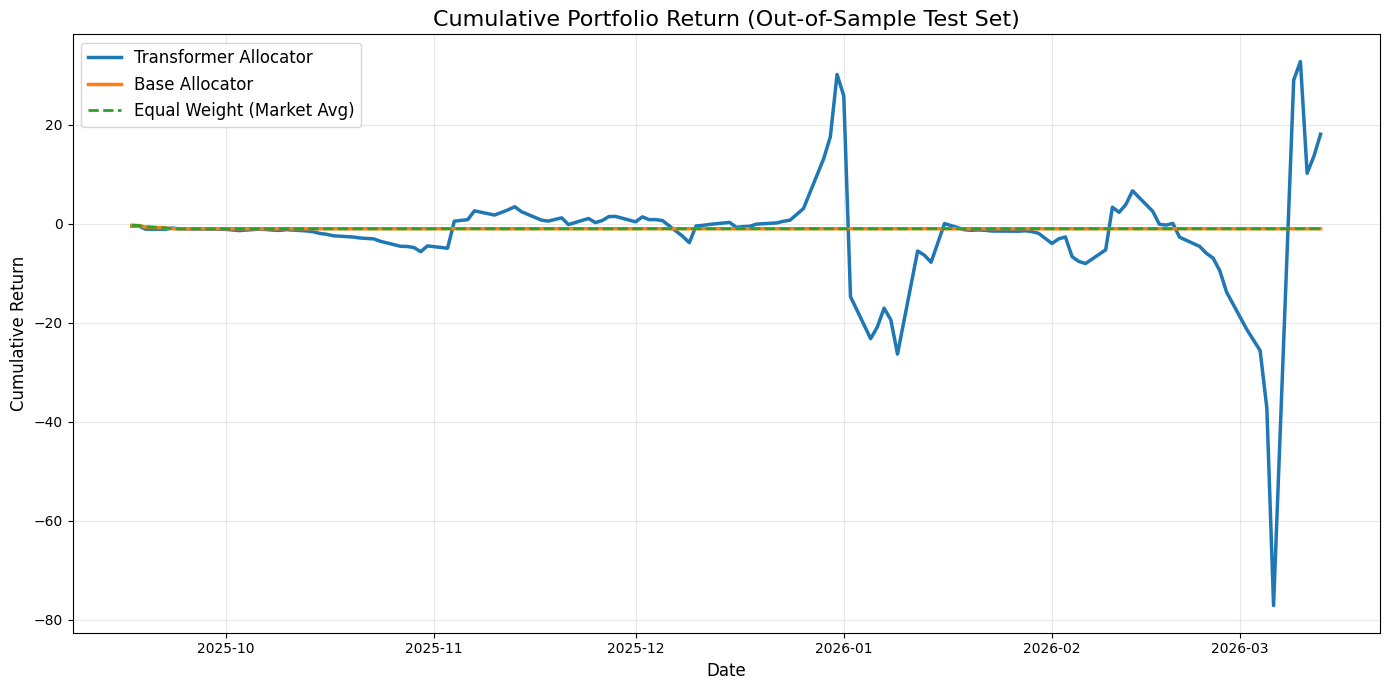

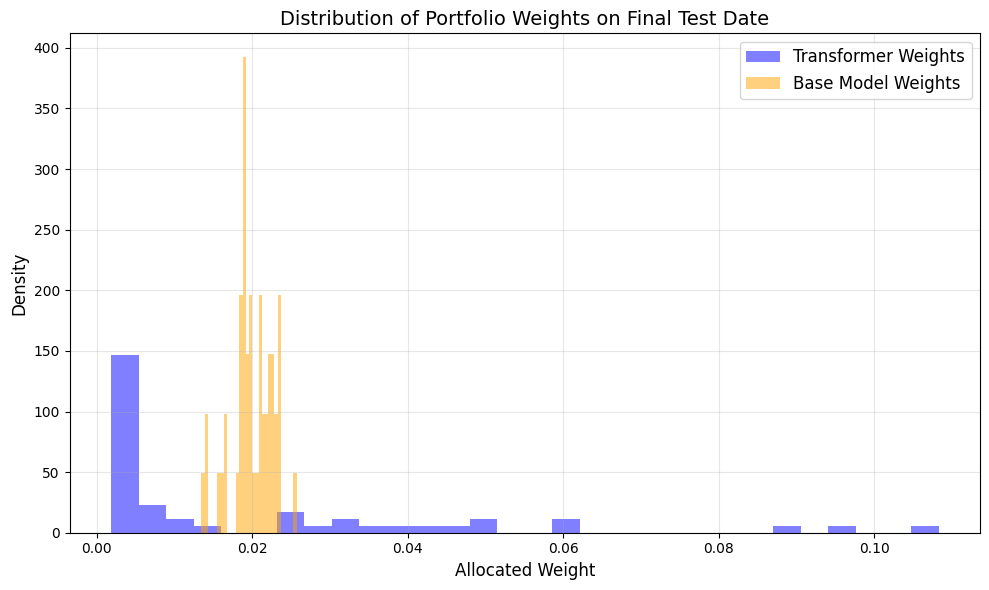

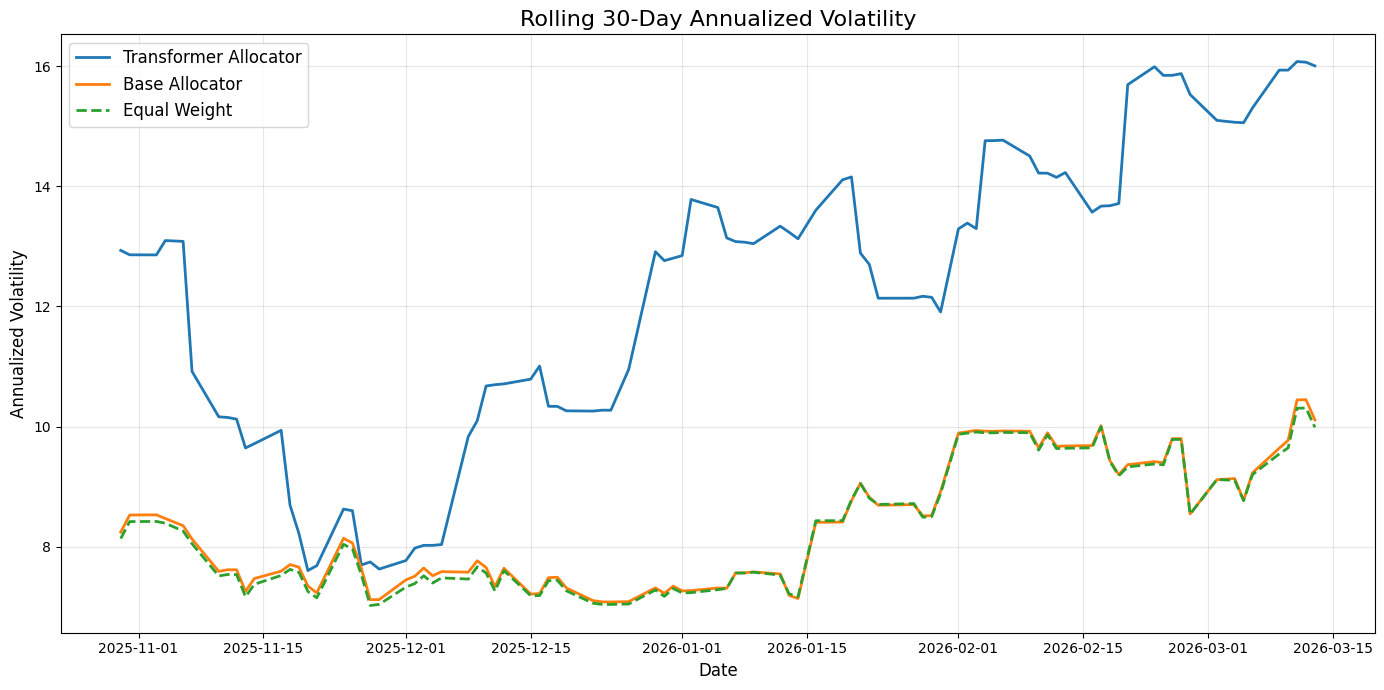

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

print("Evaluating over the entire test set to compute cumulative PnL...")

test_dates = []
tx_pnl = []
base_pnl = []
ew_pnl = []
pf_pnl = []

transformer_allocator.eval()
transformer_allocator.base_model.eval()

with torch.no_grad():
    for sample_idx in sorted(test_indices):
        d_idx = sample_idx + portfolio_dataset.seq_len - 1
        eval_date = portfolio_dataset.dates[d_idx]
        
        seq_x, target_y = portfolio_dataset[sample_idx]
        
        # Unsqueeze to add batch dim
        seq_x = seq_x.unsqueeze(0).to(device)
        
        # --- Base Model Weights (Softmax) ---
        flat_x = seq_x.view(-1, seq_x.shape[2], seq_x.shape[3])
        stock_scores = transformer_allocator.base_model(flat_x).view(50)
        base_weights = torch.softmax(stock_scores, dim=-1).cpu().numpy()
        
        # --- Transformer Model Weights ---
        tx_weights = transformer_allocator(seq_x).squeeze(0).cpu().numpy()
        
        target_y = target_y.numpy()
        
        test_dates.append(eval_date)
        tx_pnl.append(np.sum(tx_weights * target_y))
        base_pnl.append(np.sum(base_weights * target_y))
        ew_pnl.append(np.mean(target_y))
        pf_pnl.append(np.max(target_y))

# Create a DataFrame and group by date (averaging any potential duplicates just in case)
pnl_df = pd.DataFrame({
    'Date': pd.to_datetime(test_dates),
    'Transformer_PnL': tx_pnl,
    'Base_PnL': base_pnl,
    'Equal_Weight_PnL': ew_pnl,
    'Perfect_Foresight_PnL': pf_pnl
}).groupby('Date').mean().reset_index()

pnl_df.set_index('Date', inplace=True)
pnl_df.sort_index(inplace=True)

# Calculate cumulative returns
cum_pnl = (1 + pnl_df).cumprod() - 1

# =============================================================================
# Plot 1: Cumulative Returns
# =============================================================================
plt.figure(figsize=(14, 7))
plt.plot(cum_pnl.index, cum_pnl['Transformer_PnL'], label='Transformer Allocator', linewidth=2.5)
plt.plot(cum_pnl.index, cum_pnl['Base_PnL'], label='Base Allocator', linewidth=2.5)
plt.plot(cum_pnl.index, cum_pnl['Equal_Weight_PnL'], label='Equal Weight (Market Avg)', linestyle='--', linewidth=2)
# plt.plot(cum_pnl.index, cum_pnl['Perfect_Foresight_PnL'], label='Perfect Foresight', linestyle=':', linewidth=1.5, alpha=0.6)

plt.title('Cumulative Portfolio Return (Out-of-Sample Test Set)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =============================================================================
# Plot 2: Weight Distribution
# =============================================================================
plt.figure(figsize=(10, 6))
plt.hist(tx_weights, bins=30, alpha=0.5, label='Transformer Weights', color='blue', density=True)
plt.hist(base_weights, bins=30, alpha=0.5, label='Base Model Weights', color='orange', density=True)
plt.title('Distribution of Portfolio Weights on Final Test Date', fontsize=14)
plt.xlabel('Allocated Weight', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =============================================================================
# Plot 3: Rolling Volatility (30-day)
# =============================================================================
rolling_window = 30
if len(pnl_df) >= rolling_window:
    rolling_vol = pnl_df[['Transformer_PnL', 'Base_PnL', 'Equal_Weight_PnL']].rolling(window=rolling_window).std() * np.sqrt(252)
    
    plt.figure(figsize=(14, 7))
    plt.plot(rolling_vol.index, rolling_vol['Transformer_PnL'], label='Transformer Allocator', linewidth=2)
    plt.plot(rolling_vol.index, rolling_vol['Base_PnL'], label='Base Allocator', linewidth=2)
    plt.plot(rolling_vol.index, rolling_vol['Equal_Weight_PnL'], label='Equal Weight', linestyle='--', linewidth=2)
    plt.title(f'Rolling {rolling_window}-Day Annualized Volatility', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Annualized Volatility', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

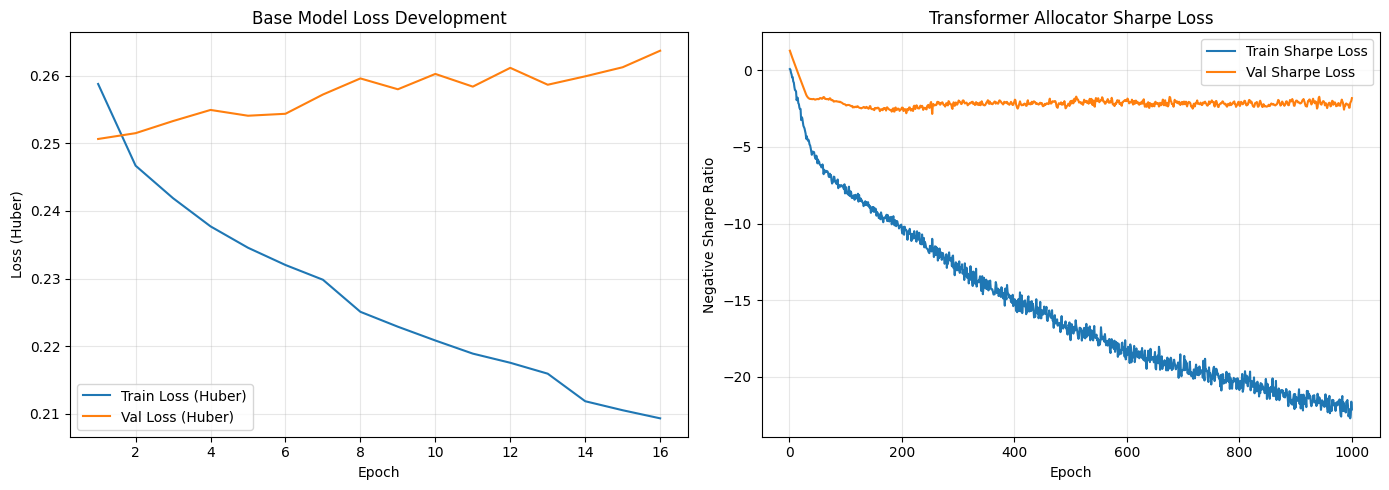

In [32]:
# =============================================================================
# 6. LOSS CURVES VISUALIZATION (Using Logged Metrics)
# =============================================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Plot Base Model
plt.subplot(1, 2, 1)
plt.plot(range(1, len(base_train_losses)+1), base_train_losses, label='Train Loss (Huber)')
plt.plot(range(1, len(base_val_losses)+1), base_val_losses, label='Val Loss (Huber)')
plt.title('Base Model Loss Development')
plt.xlabel('Epoch')
plt.ylabel('Loss (Huber)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot Transformer Model
plt.subplot(1, 2, 2)
# For the Transformer model, we log losses every epoch.
plt.plot(tx_epochs_list, tx_train_losses, label='Train Sharpe Loss')
plt.plot(tx_epochs_list, tx_val_losses, label='Val Sharpe Loss')
plt.title('Transformer Allocator Sharpe Loss')
plt.xlabel('Epoch')
plt.ylabel('Negative Sharpe Ratio')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()